# Umbrales: curva ROC y plano lluvia larga-corta

**Tesis MSc — Oscar I. Sánchez P. | Capítulo 5, Sección 5.4.4**

Dos figuras, siguiendo a Steger et al. (2023, 2024):

1. **Curva ROC con los cortes** — la mediana de las corridas Monte Carlo con su banda de incertidumbre, y sobre ella los tres cortes por TPR objetivo más el óptimo de Youden como referencia. Incluye el recuadro con la clasificación de los mapas.
2. **Plano LTR–STR, 2×2** — filas: dos slope units de terreno contrastante; columnas: El Niño y La Niña. La probabilidad predicha sobre una malla de lluvia, con los tres umbrales dibujados como isolíneas.

## Decisiones

- **Solo el paquete C.** Es el único que estima terreno y lluvia a la vez, que es lo que un umbral dinámico espacial necesita. A no tiene terreno; B tiene el rango de lluvia recortado por construcción.
- **Solo el GAM.** La logística daría isolíneas rectas y el random forest contornos escalonados, porque los árboles predicen a saltos. El GAM da superficies suaves y es lo que usan Steger et al.
- **Ejes**: LTR (30 días) en x, STR (1 día) en y. Así la figura se lee como un umbral clásico: cuanta más lluvia acumulada en el mes, menos hace falta el día del evento para cruzar la línea.
- **Los cortes se leen de `CFG['TPR_TARGETS']`**, así que si cambias los objetivos las figuras se ajustan solas.

> **Aviso de interpretación.** Las dos slope units de las filas difieren en cobertura **y** en pendiente, para que el contraste sea máximo. Eso hace la figura didáctica, pero significa que la diferencia entre filas es el efecto **conjunto** del terreno y no puede atribuirse a una sola variable. El caption debe decirlo.

> **Requisito**: correr en la misma carpeta que `mc_common.py` y `mc_set_c.py`. La celda §4 los importa para reconstruir la corrida representativa y tarda varios minutos.

## 1. Librerías y configuración

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

OUT_DIR = '/home/oisanchezp/Thesis/src/05_Chapter/Montecarlo/'
FIG_DIR = '00Figuras/05Seccion'
os.makedirs(FIG_DIR, exist_ok=True)

SET   = 'C'        # paquete de entrenamiento
MODEL = 'GAM'      # modelo con el que se construyen los umbrales

# Niveles de alerta: clave del CSV -> (etiqueta, color)
# El corte MAS PERMISIVO (TPR alto) produce el nivel MAS BAJO de alerta.
LEVELS = [
    ('P_TPR95', 'Medium',    '#f4d35e'),
    ('P_TPR85', 'High',      '#ee964b'),
    ('P_TPR70', 'Very high', '#d1495b'),
]
COLOR_LOW = '#7fb069'      # por debajo del corte mas permisivo
COLOR_OPT = '#4a4e69'      # Youden, solo como referencia

# Traducción de categorías para las etiquetas de las figuras
CAT_EN = {
    'Tejido urbano continuo':        'Continuous urban fabric',
    'Tejido urbano discontinuo':     'Discontinuous urban fabric',
    'Territorios agrícolas':         'Agricultural areas',
    'Territorios agricolas':         'Agricultural areas',
    'Tierras agrícolas':             'Agricultural areas',
    'Bosques':                       'Forests',
    'Tierras desnudas y degradadas': 'Bare and degraded land',
    'Limo-arcilloso':                'Silty clay',
    'Areno-arcilloso':               'Sandy clay',
    'Areno-limoso':                  'Sandy silt',
    'Bloques, gravas, arenas y lodos': 'Blocks, gravel, sand and mud',
    'El Niño': 'El Niño', 'La Niña': 'La Niña', 'Neutro': 'Neutral',
}


def to_en(v):
    return CAT_EN.get(str(v).strip(), str(v))

## 2. Carga de las corridas Monte Carlo

Tres archivos: las curvas ROC interpoladas, los cortes por corrida y las métricas.

In [2]:
roc = pd.read_csv(os.path.join(OUT_DIR, f'set_{SET}_mc_roc.csv'))
thr = pd.read_csv(os.path.join(OUT_DIR, f'set_{SET}_mc_thresholds.csv'))
met = pd.read_csv(os.path.join(OUT_DIR, f'set_{SET}_mc_metrics.csv'))

roc = roc[roc.model == MODEL]
thr = thr[thr.model == MODEL]
met = met[met.model == MODEL]

# Curva mediana y banda 5-95 sobre la rejilla comun de FPR
curva = (roc.groupby('fpr')['tpr']
         .agg(med='median',
              lo=lambda x: x.quantile(0.05),
              hi=lambda x: x.quantile(0.95))
         .reset_index())

# Cortes: mediana sobre las corridas
cortes = (thr.groupby('thr_level')[['threshold', 'tpr', 'fpr', 'tnr']]
          .median())

auc_med = met['auc'].median()
auc_lo, auc_hi = met['auc'].quantile([0.05, 0.95])

print(f'Corridas: {met.shape[0]} | AUROC = {auc_med:.3f} '
      f'[{auc_lo:.3f}-{auc_hi:.3f}]\n')
print(cortes.round(3).to_string())

# tabla lista para la tesis: numero esperado de alertas al ano
# DIAS_HUMEDOS: cuenta los dias del registro que superan 10 mm en 1 dia
# y 50 mm en 30 dias. Es un placeholder: reemplazalo por el conteo real.
DIAS_HUMEDOS = 120
tabla = cortes.copy()
tabla['far'] = tabla['fpr']
tabla['alertas_ano'] = (tabla['fpr'] * DIAS_HUMEDOS).round(0)
tabla.to_csv(os.path.join(OUT_DIR, f'set_{SET}_cutoffs_summary.csv'))
print('\n', tabla[['threshold', 'tpr', 'far', 'alertas_ano']].round(3).to_string())

Corridas: 94 | AUROC = 0.975 [0.955-0.989]

           threshold    tpr    fpr    tnr
thr_level                                
P_OPT          0.394  0.935  0.061  0.939
P_TPR70        0.780  0.763  0.014  0.986
P_TPR85        0.573  0.870  0.034  0.966
P_TPR95        0.201  0.959  0.119  0.881

            threshold    tpr    far  alertas_ano
thr_level                                      
P_OPT          0.394  0.935  0.061          7.0
P_TPR70        0.780  0.763  0.014          2.0
P_TPR85        0.573  0.870  0.034          4.0
P_TPR95        0.201  0.959  0.119         14.0


## 3. Figura 1 — curva ROC con los cortes

Eje horizontal en especificidad e **invertido**, como en Steger et al. (2024), de modo que el vértice perfecto queda arriba a la izquierda. La banda gris es el rango del 5 al 95 % entre las corridas.

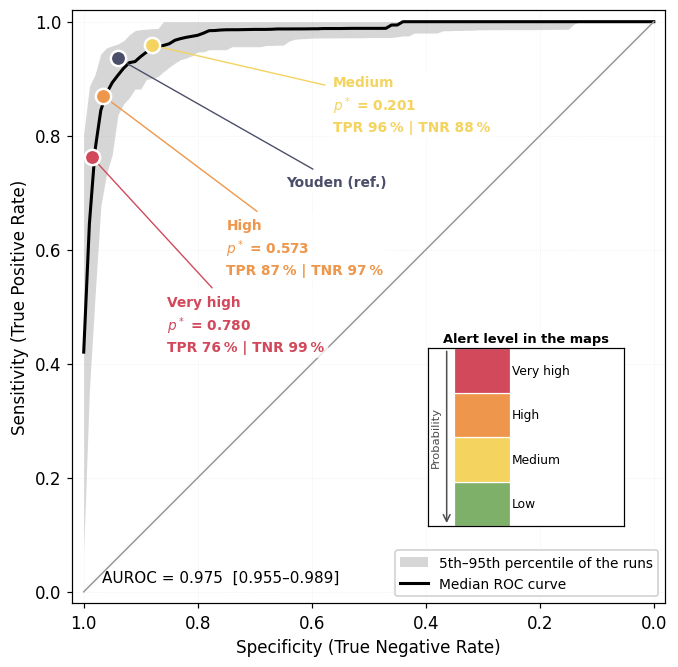

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 7.0))

spec = 1 - curva['fpr']          # especificidad
ax.fill_between(spec, curva['lo'], curva['hi'], color='0.55', alpha=.35, lw=0,
                label='5th\u201395th percentile of the runs')
ax.plot(spec, curva['med'], color='black', lw=2.0, label='Median ROC curve')
ax.plot([1, 0], [0, 1], color='0.6', lw=1.0)      # clasificacion aleatoria

# Posición de cada etiqueta en FRACCIÓN DE EJES (0 = borde izquierdo).
# Van escalonadas en el vacío bajo la curva y ordenadas de izquierda a
# derecha igual que sus puntos, que es lo que impide que las guías se crucen.
# Si al re-correr los cortes se mueven, se ajustan aquí y en ningún otro sitio.
POS_ETIQUETA = {
    'P_TPR70': (0.16, 0.47),     # Very high
    'P_TPR85': (0.26, 0.60),     # High
    'P_OPT':   (0.36, 0.71),     # Youden, solo el nombre
    'P_TPR95': (0.44, 0.84),     # Medium
}


def punto(key, etiqueta, color, con_numeros=True):
    """Dibuja el corte y lo etiqueta con una línea guía hacia el vacío."""
    if key not in cortes.index or key not in POS_ETIQUETA:
        return
    r = cortes.loc[key]
    x, y = 1 - r['fpr'], r['tpr']
    ax.plot(x, y, 'o', ms=10, mfc=color, mec='white', mew=1.6, zorder=6)

    txt = etiqueta
    if con_numeros:
        txt += (f"\n$p^*$ = {r['threshold']:.3f}\n"
                f"TPR {100*r['tpr']:.0f}\u2009% | TNR {100*r['tnr']:.0f}\u2009%")

    ax.annotate(
        txt,
        xy=(x, y), xycoords='data',                 # extremo: el punto
        xytext=POS_ETIQUETA[key], textcoords='axes fraction',
        fontsize=9, color=color, fontweight='bold',
        ha='left', va='center', linespacing=1.35, zorder=7,
        bbox=dict(boxstyle='round,pad=0.28', fc='white', ec='none', alpha=.78),
        arrowprops=dict(arrowstyle='-', color=color, lw=.9,
                        shrinkA=3, shrinkB=7,
                        connectionstyle='arc3,rad=0'))


punto('P_TPR95', 'Medium',        LEVELS[0][2])
punto('P_TPR85', 'High',          LEVELS[1][2])
punto('P_TPR70', 'Very high',     LEVELS[2][2])
punto('P_OPT',   'Youden (ref.)', COLOR_OPT, con_numeros=False)

ax.set_xlim(1.02, -0.02)         # especificidad invertida
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('Specificity (True Negative Rate)')
ax.set_ylabel('Sensitivity (True Positive Rate)')
ax.grid(alpha=.25, lw=.5, ls=':')
ax.set_axisbelow(True)
ax.set_aspect('equal')

ax.annotate(f'AUROC = {auc_med:.3f}  [{auc_lo:.3f}\u2013{auc_hi:.3f}]',
            xy=(0.05, 0.03), xycoords='axes fraction', fontsize=10,
            ha='left', va='bottom')
ax.legend(loc='lower right', fontsize=9, framealpha=.95)

# --- recuadro con la clasificacion de los mapas ----------------------
ins = ax.inset_axes([0.60, 0.13, 0.33, 0.30])
ins.set_xticks([]); ins.set_yticks([])
ins.set_title('Alert level in the maps', fontsize=8.5, fontweight='bold', pad=4)
bandas = [(COLOR_LOW, 'Low'), (LEVELS[0][2], 'Medium'),
          (LEVELS[1][2], 'High'), (LEVELS[2][2], 'Very high')]
for i, (c, lab) in enumerate(bandas):
    ins.add_patch(Rectangle((0.09, i * 0.25), 0.30, 0.25,
                            facecolor=c, edgecolor='white', lw=.8))
    ins.text(0.40, i * 0.25 + 0.125, lab, va='center', fontsize=8)
ins.annotate('', xy=(0.05, 1.0), xytext=(0.05, 0.0),
             arrowprops=dict(arrowstyle='<-', lw=1.0, color='0.3'))
ins.text(0.02, 0.5, 'Probability', rotation=90, va='center', ha='right',
         fontsize=7.5, color='0.3')
ins.set_xlim(-0.05, 1); ins.set_ylim(0, 1)

fig.savefig(os.path.join(FIG_DIR, f'fig_roc_cutoffs_{SET}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, f'fig_roc_cutoffs_{SET}.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4. Reconstrucción de la corrida representativa

Para el plano LTR–STR hace falta un modelo ajustado. Se reconstruye la corrida cuyo AUROC del GAM está más cerca de la mediana, con la misma semilla, igual que en la Sección 5.4.3. **Tarda varios minutos.**

In [4]:
from sklearn.model_selection import GroupShuffleSplit
from mc_common import CFG, make_models, GamWrapper, _proba1
import mc_set_c

med = met['auc'].median()
run_star = int(met.loc[(met['auc'] - med).abs().idxmin(), 'run_id'])
seed = CFG['BASE_SEED'] + run_star
print('Corrida representativa:', run_star, '| seed:', seed)

NUM = ['T', 'P', 'slope_mean', 'curva_mean']
CAT = ['cobertura', 'suelos', 'ENSO']
FEAT = NUM + CAT

df = mc_set_c.build_dataset(seed)
df = df.dropna(subset=['si_no'] + FEAT).copy().reset_index(drop=True)
y = df['si_no'].astype(int).to_numpy()
Xdf = df[FEAT].copy()
for c in CAT:
    Xdf[c] = Xdf[c].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=CFG['TEST_SIZE'],
                        random_state=seed)
itr, ite = next(gss.split(Xdf, y, groups=df['su_uid'].to_numpy()))

gam = make_models(NUM, CAT, seed)['GAM']
gam.fit(Xdf.iloc[itr], y[itr], seed=seed)
print(f'GAM ajustado | n={len(y)} | train={len(itr)} | test={len(ite)}')

2026-09-05 22:00:25,522 | INFO    | ======================================================================
2026-09-05 22:00:25,524 | INFO    | INICIO set_C: 2026-09-05T22:00:25
2026-09-05 22:00:25,525 | INFO    | EXCL_DAYS_C = 0 | MATCH_TIME = True
2026-09-05 22:01:01,373 | INFO    | su_uid tomado de la columna 'su_id'
2026-09-05 22:01:01,380 | INFO    | su_uid: 61167 filas | 61073 unidades distintas | 94 filas extra por unidades multi-evento
2026-09-05 22:01:01,412 | INFO    | Hold-out desde 2025-04-01: 57 eventos reservados -> /home/oisanchezp/Thesis/src/05_Chapter/Montecarlo/holdout_events.csv
2026-09-05 22:01:01,462 | INFO    | Slope units: 61110 | filas evento para entrenar: 435
2026-09-05 22:02:20,963 | INFO    | SU ausencia elegibles (>200 m de un evento): 55128 de 60675
2026-09-05 22:02:21,203 | INFO    |   Est.    1: 2010-01-12 -> 2026-03-18 |  94.0% con dato | 1985 duplicados
2026-09-05 22:02:21,341 | INFO    |   Est.    2: 2010-01-01 -> 2026-03-18 |  90.7% con dato | 249 dup

Corrida representativa: 2 | seed: 102


2026-09-05 22:02:44,125 | INFO    |   anos presencias: {2016: 2, 2017: 2, 2019: 1, 2020: 1, 2021: 71, 2022: 168, 2023: 66, 2024: 55}
2026-09-05 22:02:44,129 | INFO    |   anos ausencias : {2016: 2, 2017: 3, 2019: 6, 2020: 2, 2021: 118, 2022: 310, 2023: 158, 2024: 133}
2026-09-05 22:02:44,132 | INFO    |   meses presencias: {1: 11, 3: 21, 4: 20, 5: 74, 6: 72, 7: 2, 8: 23, 9: 34, 10: 41, 11: 61, 12: 7}
2026-09-05 22:02:44,135 | INFO    |   meses ausencias : {1: 24, 3: 39, 4: 36, 5: 168, 6: 150, 7: 3, 8: 55, 9: 68, 10: 82, 11: 104, 12: 3}
2026-09-05 22:02:44,136 | INFO    |   dataset: SI=366 | NO=732 | total=1098


GAM ajustado | n=1096 | train=881 | test=215


## 5. Selección de las dos slope units y de la malla

**Fila 1**: tejido urbano continuo con la pendiente más alta.
**Fila 2**: bosque con la pendiente más baja.

Se eligen así para que el contraste sea máximo: la cobertura urbana sube la probabilidad, el bosque la baja, y la pendiente añade su propio efecto. Es la mejor combinación para una figura didáctica, pero implica que la diferencia entre filas es el efecto **conjunto** del terreno y no el de una variable aislada.

In [5]:
# --- combinaciones a representar --------------------------------------
# Columnas: cobertura (tejido urbano continuo vs bosque)
# Filas   : fase ENSO (El Niño vs La Niña)
# El resto de las estáticas se FIJA igual en los cuatro paneles, de modo
# que la diferencia entre columnas sea atribuible SOLO a la cobertura y
# la diferencia entre filas SOLO a la fase ENSO.
SLOPE_FIX = 32.0

def _clase(patron, etiqueta):
    v = df['cobertura'].astype(str)
    m = v.str.contains(patron, case=False, na=False)
    if not m.any():
        raise ValueError(f'No hay filas de {etiqueta}. Disponibles: '
                         f'{sorted(v.unique())}')
    return v[m].iloc[0]

COB_COLS  = [_clase('urbano continuo|Continuous urban', 'tejido urbano continuo'),
             _clase('Bosque|Forest', 'bosque')]
ENSO_ROWS = ['El Niño', 'La Niña']

CURV_FIX  = float(df['curva_mean'].median())
SUELO_FIX = df['suelos'].astype(str).mode().iloc[0]

print(f'Pendiente fija : {SLOPE_FIX:.0f}\u00b0')
print(f'Curvatura fija : {CURV_FIX:.5f}  (mediana)')
print(f'Suelo fijo     : {to_en(SUELO_FIX)}  (clase más frecuente)')
print(f'Columnas       : {[to_en(c) for c in COB_COLS]}')
print(f'Filas          : {[to_en(e) for e in ENSO_ROWS]}')

# --- malla de lluvia ---------------------------------------------------
LTR_MAX = float(np.nanpercentile(df['P'], 99.5))
STR_MAX = float(np.nanpercentile(df['T'], 99.5))
ltr_g = np.linspace(0, LTR_MAX, 160)      # eje x
str_g = np.linspace(0, STR_MAX, 160)      # eje y
LL, SS = np.meshgrid(ltr_g, str_g)
print(f'\nMalla: LTR 0-{LTR_MAX:.0f} mm | STR 0-{STR_MAX:.0f} mm')

Pendiente fija : 32°
Curvatura fija : -0.00008  (mediana)
Suelo fijo     : Sandy silt  (clase más frecuente)
Columnas       : ['Continuous urban fabric', 'Forests']
Filas          : ['El Niño', 'La Niña']

Malla: LTR 0-526 mm | STR 0-115 mm


## 6. Figura 2 — plano LTR–STR, 2×2

Filas: las dos slope units. Columnas: El Niño y La Niña. Los cuatro paneles comparten ejes y escala de color, que es lo que permite comparar.

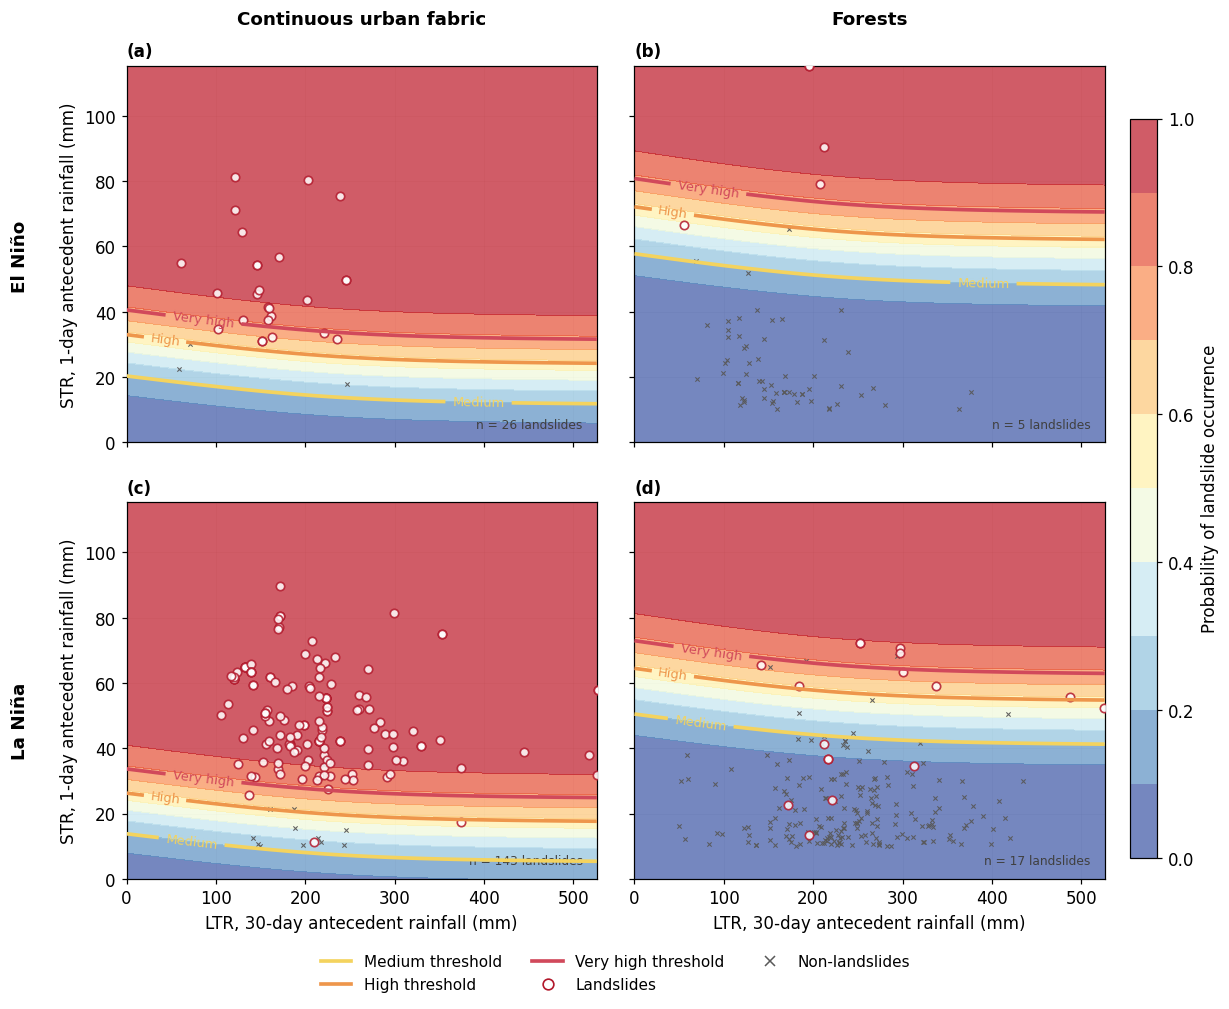

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11.4, 9.6), sharex=True, sharey=True)
niveles = np.linspace(0, 1, 11)
letras = [['a', 'b'], ['c', 'd']]

for i, fase in enumerate(ENSO_ROWS):            # filas: ENSO
    for j, cob in enumerate(COB_COLS):          # columnas: cobertura
        ax = axes[i][j]

        # Todo fijo salvo la cobertura (columna) y la fase ENSO (fila).
        grid = pd.DataFrame({'T': SS.ravel(), 'P': LL.ravel()})
        grid['slope_mean'] = SLOPE_FIX
        grid['curva_mean'] = CURV_FIX
        grid['cobertura']  = cob
        grid['suelos']     = SUELO_FIX
        grid['ENSO']       = fase
        prob = _proba1(gam, grid[FEAT]).reshape(SS.shape)

        cf = ax.contourf(ltr_g, str_g, prob, levels=niveles,
                         cmap='RdYlBu_r', alpha=.7)

        for key, lab, col in LEVELS:
            if key not in cortes.index:
                continue
            p = cortes.loc[key, 'threshold']
            cs = ax.contour(ltr_g, str_g, prob, levels=[p],
                            colors=[col], linewidths=2.4, zorder=4)
            ax.clabel(cs, fmt={p: lab}, fontsize=8.5, inline=True)
        # if 'P_OPT' in cortes.index:
        #     p = cortes.loc['P_OPT', 'threshold']
        #     cs = ax.contour(ltr_g, str_g, prob, levels=[p], colors=[COLOR_OPT],
        #                     linewidths=1.8, linestyles='--', zorder=4)
        #     ax.clabel(cs, fmt={p: 'Youden'}, fontsize=8, inline=True)

        # observaciones de esa fase ENSO y esa cobertura
        sub = df[(df['ENSO'].astype(str) == fase) &
                 (df['cobertura'].astype(str) == cob)]
        ax.scatter(sub.loc[sub.si_no == 0, 'P'], sub.loc[sub.si_no == 0, 'T'],
                   s=8, marker='x', c='0.35', alpha=.95, lw=.7, zorder=2, facecolors='black')
        ax.scatter(sub.loc[sub.si_no == 1, 'P'], sub.loc[sub.si_no == 1, 'T'],
                   s=30, marker='o', facecolor='white', edgecolor='#b2182b',
                   lw=1.1, alpha=.85, zorder=3)
        ax.annotate(f'n = {int((sub.si_no == 1).sum())} landslides',
                    xy=(0.97, 0.03), xycoords='axes fraction',
                    ha='right', va='bottom', fontsize=8, color='0.25')

        ax.set_xlim(0, LTR_MAX); ax.set_ylim(0, STR_MAX)
        ax.set_title(f'({letras[i][j]})', loc='left', fontsize=11)
        if i == 0:                               # encabezado de columna
            ax.text(0.5, 1.10, to_en(cob), transform=ax.transAxes,
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
        if i == 1:
            ax.set_xlabel('LTR, 30-day antecedent rainfall (mm)')
        if j == 0:
            ax.set_ylabel('STR, 1-day antecedent rainfall (mm)')
        ax.grid(alpha=.18, lw=.5)
        ax.set_axisbelow(True)

# etiquetas de fila (fase ENSO), a la izquierda de la figura
for i, fase in enumerate(ENSO_ROWS):
    fig.text(0.015, 0.72 - i * 0.44, to_en(fase), rotation=90,
             va='center', ha='center', fontsize=12, fontweight='bold')

#fig.suptitle(f'Slope {SLOPE_FIX:.0f}\u00b0 \u00b7 {to_en(SUELO_FIX)} \u00b7 '
#             f'median curvature', fontsize=10, y=0.965, color='0.3')

fig.subplots_adjust(left=0.10, right=0.88, top=0.90, bottom=0.13,
                    hspace=0.16, wspace=0.08)

cax = fig.add_axes([0.90, 0.15, 0.022, 0.70])
cb = fig.colorbar(cf, cax=cax)
cb.set_label('Probability of landslide occurrence')

handles = [Line2D([], [], color=c, lw=2.4, label=f'{lab} threshold')
           for _, lab, c in LEVELS]
handles += [
            Line2D([], [], marker='o', color='w', mfc='white', mec='#b2182b',
                   mew=1.1, ms=7, ls='none', label='Landslides'),
            Line2D([], [], marker='x', color='0.35', ls='none', ms=6,
                   label='Non-landslides')]

# Line2D([], [], color=COLOR_OPT, lw=1.8, ls='--',
#                    label='Youden (reference)'),

fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.49, 0.01),
           ncol=3, fontsize=10, frameon=False)

fig.savefig(os.path.join(FIG_DIR, f'fig_tp_thresholds_{SET}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, f'fig_tp_thresholds_{SET}.png'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Los umbrales en milímetros

Cuánta lluvia de un día hace falta para cruzar cada umbral, en cada slope unit y cada fase ENSO, bajo condiciones antecedentes seca, media y húmeda (percentiles 25, 50 y 75 del LTR observado).

**Esta es la tabla que le sirve al operador**, y es la traducción directa de las isolíneas de la figura anterior a un número comparable con los umbrales empíricos de la literatura.

In [13]:
ltr_q = np.nanpercentile(df['P'], [25, 50, 75])
print('LTR de referencia (mm):', np.round(ltr_q, 0))
filas = []
for fase in ENSO_ROWS:
    for cob in COB_COLS:
        for lab_q, ltr_v in zip(['dry (P25)', 'average (P50)', 'wet (P75)'], ltr_q):
            g = pd.DataFrame({'T': str_g, 'P': ltr_v})
            g['slope_mean'] = SLOPE_FIX
            g['curva_mean'] = CURV_FIX
            g['cobertura']  = cob
            g['suelos']     = SUELO_FIX
            g['ENSO']       = fase
            pr = _proba1(gam, g[FEAT])
            r = {'land cover': to_en(cob), 'slope': SLOPE_FIX,
                 'ENSO': to_en(fase), 'LTR': lab_q}
            for key, lab, _ in LEVELS:
                if key not in cortes.index:
                    continue
                p = cortes.loc[key, 'threshold']
                idx = np.where(pr >= p)[0]
                r[f'STR for {lab}'] = round(float(str_g[idx[0]]), 1) if len(idx) else np.nan
            filas.append(r)

umbrales_mm = pd.DataFrame(filas)
print('\n', umbrales_mm.to_string(index=False))
umbrales_mm.to_csv(os.path.join(OUT_DIR, f'set_{SET}_thresholds_mm.csv'),
                   index=False)
print('\nNaN = ese umbral no se alcanza dentro del rango de la malla.')

LTR de referencia (mm): [171. 221. 270.]

              land cover  slope    ENSO           LTR  STR for Medium  STR for High  STR for Very high
Continuous urban fabric   32.0 El Niño     dry (P25)            15.2          28.3               35.5
Continuous urban fabric   32.0 El Niño average (P50)            14.5          26.8               34.1
Continuous urban fabric   32.0 El Niño     wet (P75)            13.8          26.1               33.4
                Forests   32.0 El Niño     dry (P25)            52.2          66.7               74.7
                Forests   32.0 El Niño average (P50)            51.5          65.3               74.0
                Forests   32.0 El Niño     wet (P75)            50.0          64.5               72.5
Continuous urban fabric   32.0 La Niña     dry (P25)             9.4          21.8               29.0
Continuous urban fabric   32.0 La Niña average (P50)             8.0          20.3               27.6
Continuous urban fabric   32.0 La Niña 

In [12]:
# --- versión LaTeX de la tabla de umbrales en milímetros --------------
cols_str = [c for c in umbrales_mm.columns if c.startswith('STR for')]
print('\\renewcommand{\\arraystretch}{1.2}')
print('\\begin{table}[ht]\n\\centering\n\\footnotesize')
print('\\begin{tabular}{llll ' + 'c' * len(cols_str) + '}')
print('\\hline')
print('\\textbf{Land cover} & \\textbf{Slope} & \\textbf{ENSO} & '
      '\\textbf{Antecedent} & '
      + ' & '.join(f'\\textbf{{{c.replace("STR for ", "")}}}' for c in cols_str)
      + ' \\\\')
print('\\hline')
prev = None
for _, r in umbrales_mm.iterrows():
    clave = (r['land cover'], r['ENSO'])
    lc = r['land cover'] if clave != prev else ''
    sl = f"{r['slope']:.0f}$^\\circ$" if clave != prev else ''
    en = r['ENSO'] if clave != prev else ''
    prev = clave
    vals = ' & '.join('--' if pd.isna(r[c]) else f"{r[c]:.0f}" for c in cols_str)
    print(f"{lc} & {sl} & {en} & {r['LTR']} & {vals} \\\\")
print('\\hline\n\\end{tabular}')
print('\\caption{Short-term rainfall, in millimetres, required to reach each '
      'alert level in two slope units of contrasting terrain, under the two '
      'ENSO phases and three antecedent wetness conditions given by the 25th, '
      '50th and 75th percentiles of the long-term rainfall. A dash means that '
      'the level is not reached within the observed rainfall range.}')
print('\\label{tab:th-thresholds-mm}\n\\end{table}')

\renewcommand{\arraystretch}{1.2}
\begin{table}[ht]
\centering
\footnotesize
\begin{tabular}{llll ccc}
\hline
\textbf{Land cover} & \textbf{Slope} & \textbf{ENSO} & \textbf{Antecedent} & \textbf{Medium} & \textbf{High} & \textbf{Very high} \\
\hline
Continuous urban fabric & 32$^\circ$ & El Niño & dry (P25) & 15 & 28 & 36 \\
 &  &  & average (P50) & 14 & 27 & 34 \\
 &  &  & wet (P75) & 14 & 26 & 33 \\
Forests & 32$^\circ$ & El Niño & dry (P25) & 52 & 67 & 75 \\
 &  &  & average (P50) & 52 & 65 & 74 \\
 &  &  & wet (P75) & 50 & 64 & 72 \\
Continuous urban fabric & 32$^\circ$ & La Niña & dry (P25) & 9 & 22 & 29 \\
 &  &  & average (P50) & 8 & 20 & 28 \\
 &  &  & wet (P75) & 7 & 20 & 27 \\
Forests & 32$^\circ$ & La Niña & dry (P25) & 45 & 59 & 67 \\
 &  &  & average (P50) & 44 & 58 & 66 \\
 &  &  & wet (P75) & 44 & 57 & 65 \\
\hline
\end{tabular}
\caption{Short-term rainfall, in millimetres, required to reach each alert level in two slope units of contrasting terrain, under the two ENSO p

---

## Captions sugeridos

```latex
\caption{ROC curve of the generalized additive model fitted on training set C and the three probability cut-offs derived from it. The black line is the median over the Monte Carlo runs and the grey band the 5th to 95th percentile. Each point gives the cut-off $p^*$ and the true positive and true negative rates it achieves; the Youden point is shown as a reference but is not used operationally. The inset shows how the three cut-offs divide the probability range into the four alert levels of the dynamic maps.}
\label{fig:th-roc}
```

```latex
\caption{Rainfall thresholds for two slope units of contrasting terrain under two ENSO phases. Colours show the probability of landslide occurrence predicted by the additive model over a grid of long-term (horizontal axis) and short-term (vertical axis) antecedent rainfall, with the static predictors fixed at the values of each unit. The coloured lines are the three cut-offs of Fig.~\ref{fig:th-roc} and read as classical rainfall thresholds: the wetter the previous month, the less rain is needed on the day itself to cross a given line. The two units differ in land cover and in slope angle at the same time, so the difference between rows is the joint effect of the terrain and cannot be attributed to either variable alone. Points are the landslide and non-landslide observations of the representative run for the corresponding ENSO phase, shown as a reference of where the data lie; they belong to all slope units and not only to the one of each row.}
\label{fig:th-tpthresholds}
```